# MLP with hyperparameter Tuning [(medium-article)](https://medium.com/@vijaikdasari/multilayer-perceptron-and-its-hyperparameter-tuning-deedfbca2d1b)

- Grid search --> all combinations, smaller networks + limited hyperparameter ranges
- Random search --> random combinations, high-dimensional hyperparameter spaces
- Bayesian optimization --> probabilistic model that balances exploration (trying new hyperparameter combinations) and exploitation (refining around known good values), complex model + large datasets
- Automated Machine Learning (AutoML) Tools --> flexible hyperparameter search configurations, Keras Tuner / Optuna

## Import

In [2]:
%load_ext autoreload
%autoreload 2

In [55]:
from src.config import RANDOM_SEED
import src.pipeline as pipe
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import optuna
import pickle
import numpy as np
import tensorflow as tf
from optuna.samplers import TPESampler, RandomSampler

## Setup

In [70]:
# INDICATORS = [i for i in df.columns if i != 'Year']
# per ora lo faccio solo su sti tre per capire se funziona
INDICATORS = ['Fertilizer consumption (% of fertilizer production)',
            'Agriculture, forestry, and fishing, value added (% of GDP)']
# 'Agricultural raw materials imports (% of merchandise imports)'
# 'Rural population (% of total population)'
# 'Cereal yield (kg per hectare)'
# 'Crop production index (2014-2016 = 100)'

DF_CATEGORIES = ["orig", "step_aug", "jitter_aug"]

## Upload

In [71]:
df = pipe.load_data()
display(df.head())

Dataset caricato: 65 anni, 28 variabili.


,Year,Agricultural land (% of land area),Agricultural land (sq. km),Agricultural raw materials exports (% of merchandise exports),Agricultural raw materials imports (% of merchandise imports),"Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (current US$)","Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)",Arable land (% of land area),Arable land (hectares per person),...,Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land under cereal production (hectares),Livestock production index (2014-2016 = 100),Permanent cropland (% of land area),Rural population,Rural population (% of total population),Rural population growth (annual %)
0,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20400656.0,40.639,NaN
1,1961,70.324028,206830.0,NaN,NaN,NaN,NaN,NaN,43.731937,0.254510,...,67.795055,85.93,NaN,NaN,6387203.0,70.91,9.336643,20287312.0,40.144,-0.557139
2,1962,70.218626,206520.0,2.563660,16.566057,NaN,NaN,NaN,43.504131,0.251477,...,69.362485,86.90,NaN,NaN,6485855.0,72.59,9.435245,20171158.0,39.645,-0.574190
3,1963,69.735813,205100.0,2.651714,14.571604,NaN,NaN,NaN,43.092720,0.247288,...,68.764636,86.37,NaN,NaN,6299467.0,65.95,9.319642,20063620.0,39.147,-0.534554
4,1964,69.572609,204620.0,2.792923,15.115329,NaN,NaN,NaN,42.834314,0.243791,...,74.639625,90.28,NaN,NaN,6244904.0,69.57,9.438645,19972523.0,38.650,-0.455075


## Splitting + augmentation + saving
- splitting della time serie originale in train, validation e test set,
- augmentation su train set originale (prevent data leakage) con step function e linear interpolation + jitter,
- creazione di un dizionario che contiene tutte queste cose

l'orizzonte di test è adattivo in base alla disponibilità dei dati storici di ciascun indicatore. Siccome serie sono corte ho dato priorità ad avere un punto in più nel validation set piuttosto che nel test set

============================== FERTILIZER CONSUMPTION (% OF FERTILIZER PRODUCTION) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)


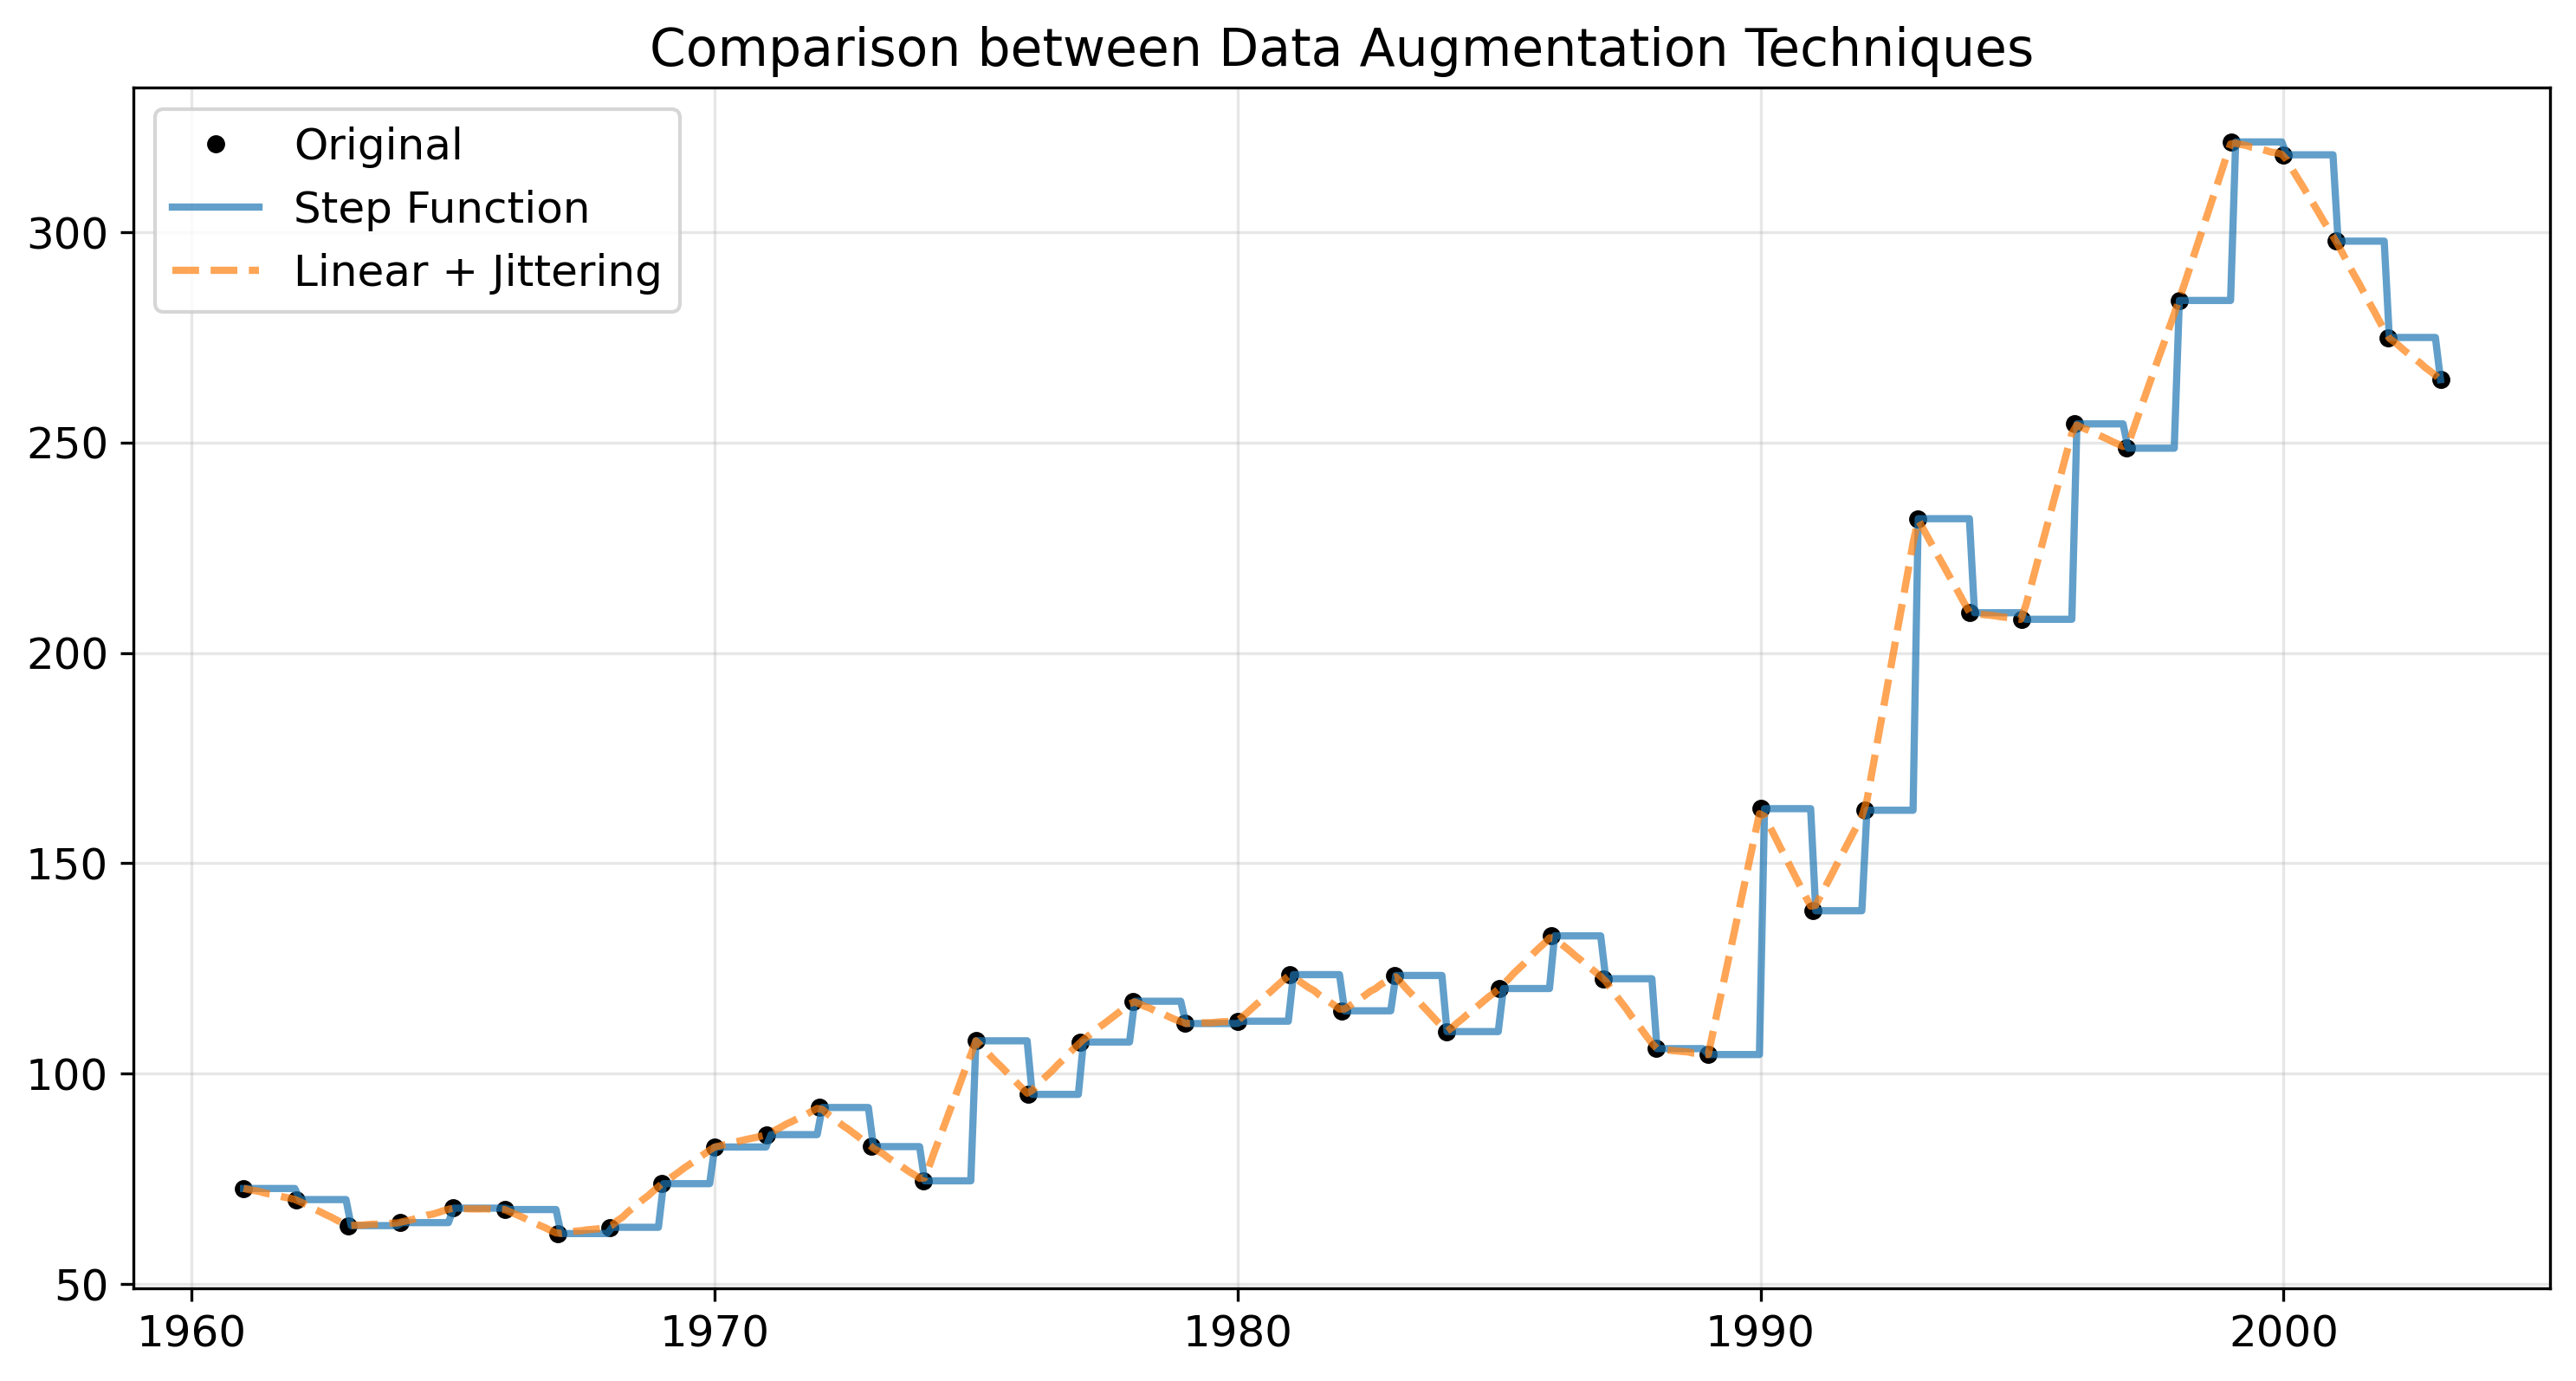

============================== AGRICULTURE, FORESTRY, AND FISHING, VALUE ADDED (% OF GDP) ==============================
Train: 1990-2013 (24 obs)
Val:   2014-2019 (6 obs)
Test:  2020-2024 (5 obs)


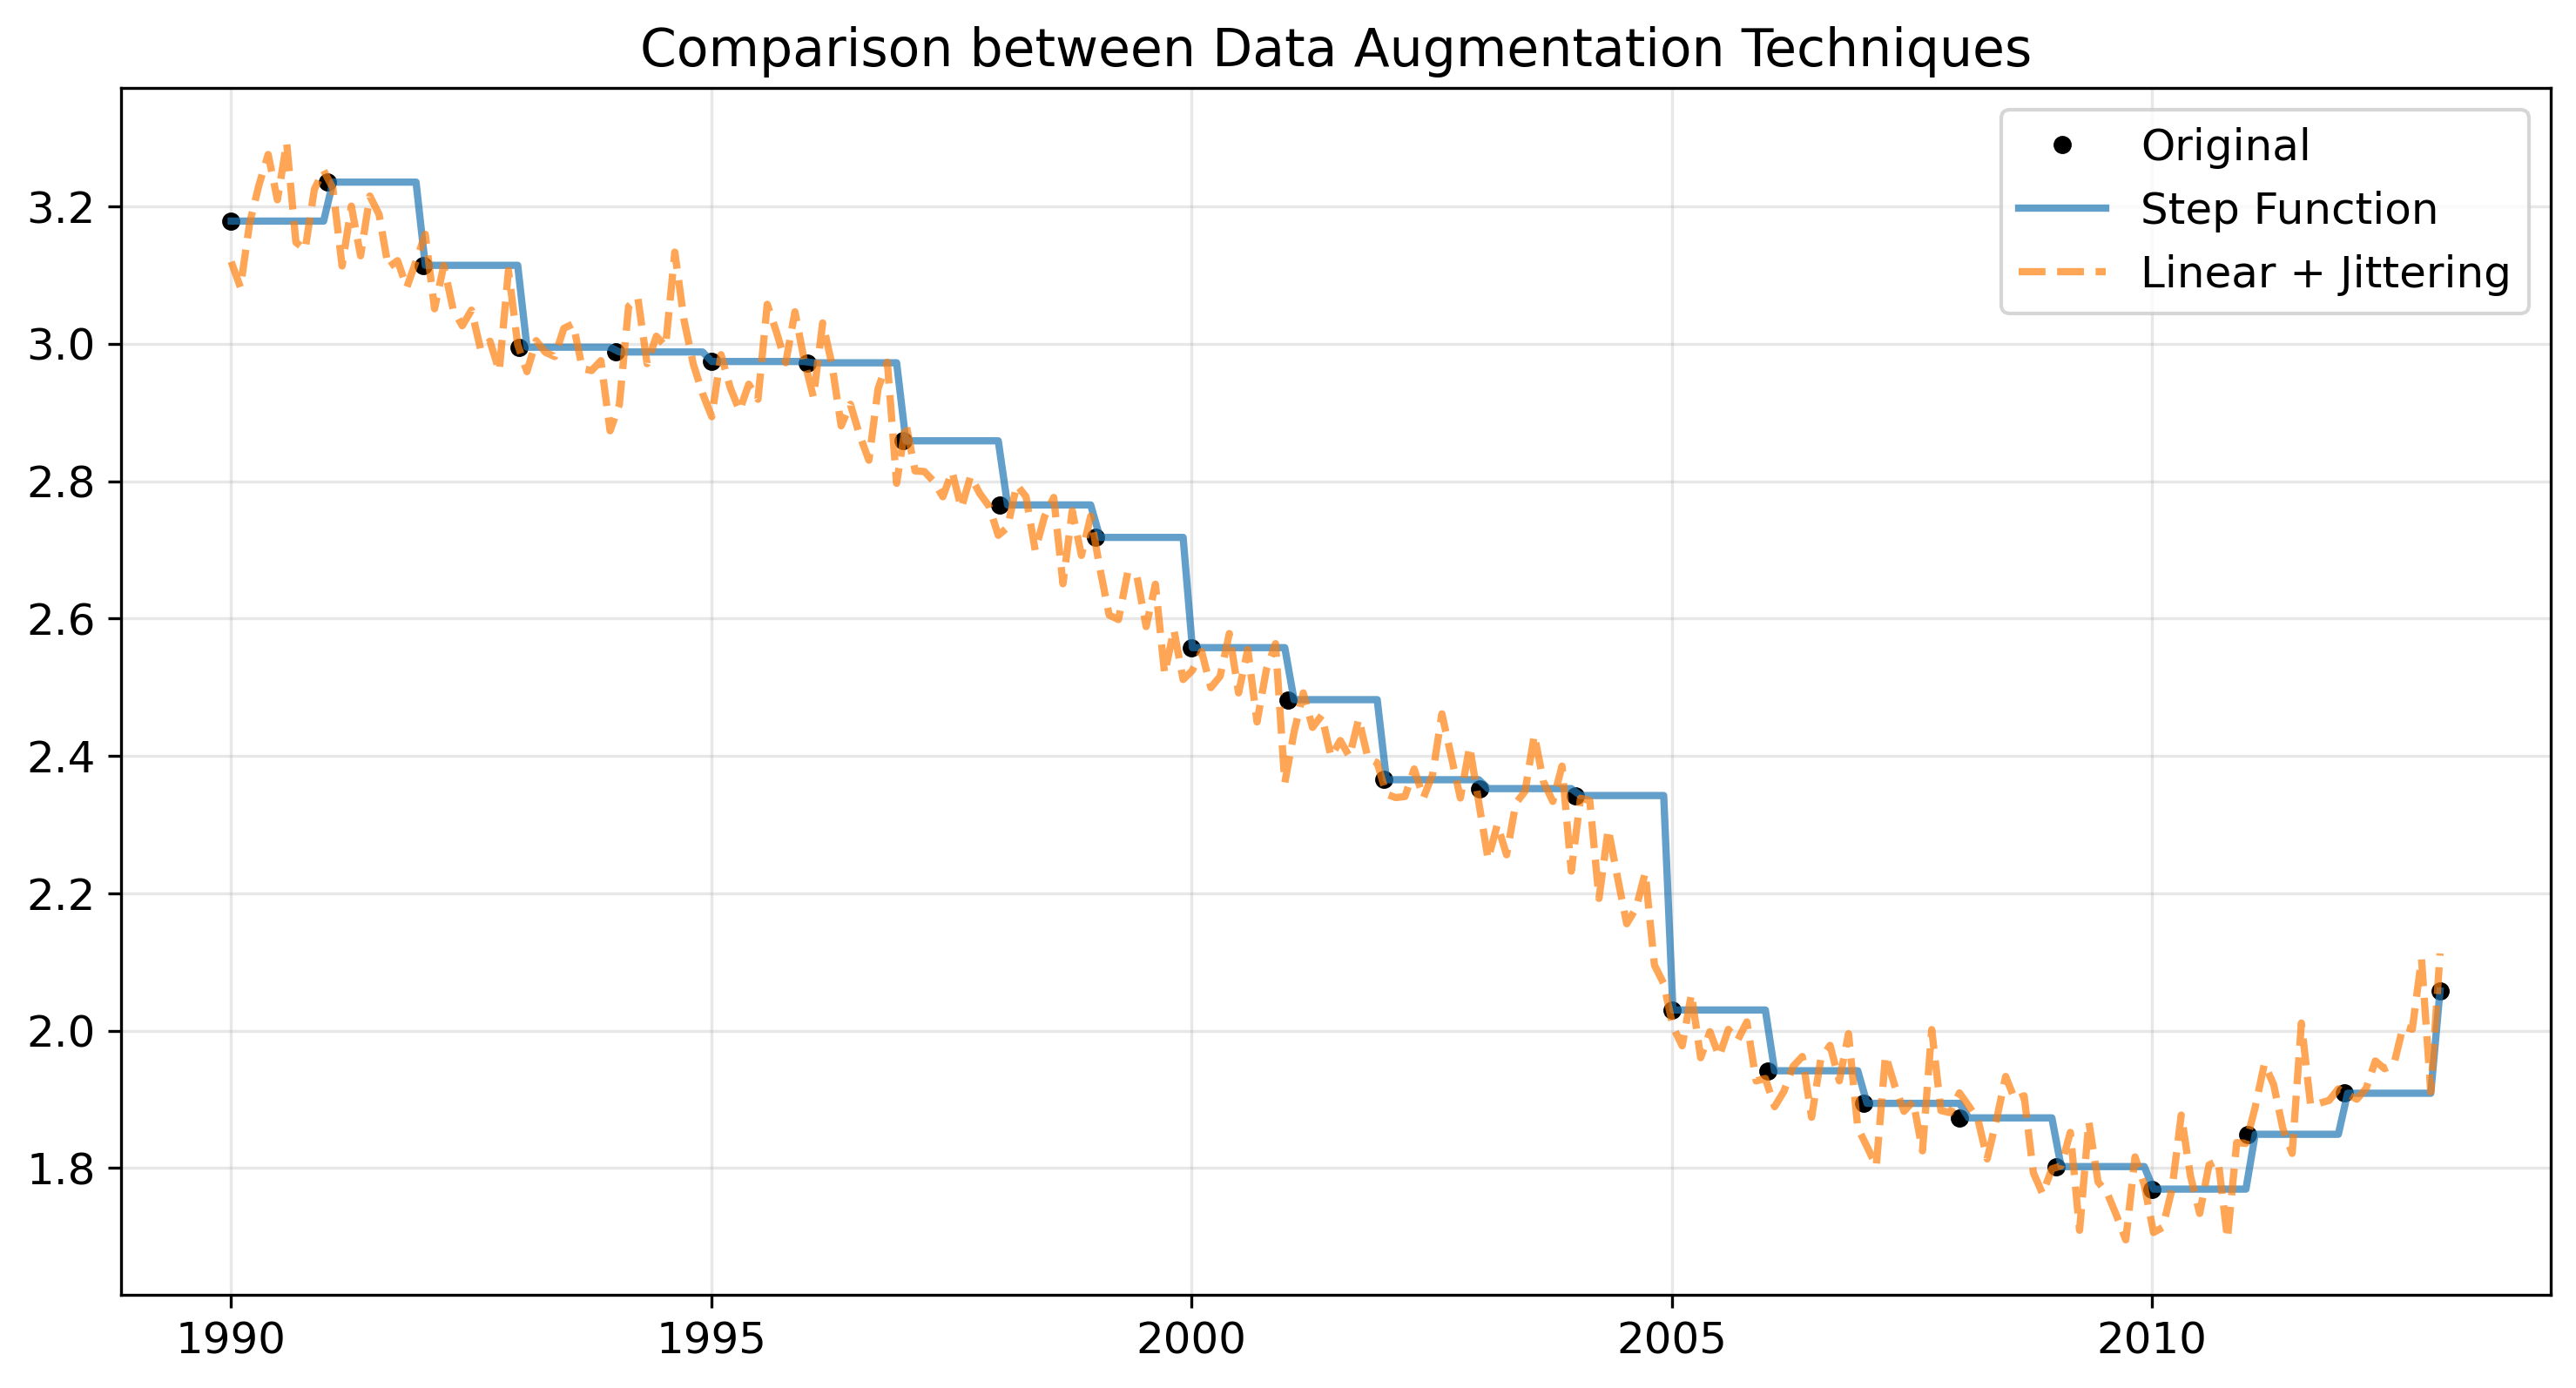

In [ ]:
# dizionario per salvare in memoria i subset originali e i train aumentati con step e linear
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = pipe.split_train_val_test(df_temp)    # splitto la time serie ORIGINALE
    
    # faccio augmentation SOLO sul train set: aumento sia anni che valori
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    visual.plot_augmented(indicator, df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'full_orig': df_temp,
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

## Scaling
- scaling di tutto ciò che è all'interno del dizionario facendo fit su valori del train originale (diviso per anno e valore) e transform sui dataframe aumentati.

In [73]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}

for indicator in INDICATORS:
    scaled_subsets, scalers = pipe.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

## Definition of search space = objective function for RandomSearch and Optuna

In [74]:
def objective(trial, scaled_data_dict):
    """
    Defines an objective function that is used in hyperparameter optimization, specifically with Optuna.
    
    Args: 
        trial = which is an Optuna Trial object used to sample hyperparameters
        scaled_data_dict = contains scaled training and validation data
        
    Returns:
        best_val_loss = minimum validation loss gotten
    """
    
    params = {
        # iperparametri riguardanti la struttura della rete
        'n_layers': trial.suggest_int('n_layers', 1, 3),
        'units': trial.suggest_int('units', 8, 64),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        
        # iperparametri riguardanti traning
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [8, 16, 32]),
        'dropout': trial.suggest_categorical('dropout', [0.1, 0.2, 0.3])
    }
    
    # iperparametri riguardanti i dati
    n_input_steps = trial.suggest_categorical('n_input_steps', [3, 5, 10])
    
    train_data = scaled_data_dict['train'] 
    val_data = scaled_data_dict['val']
    
    X_train, y_train = pipe.create_sequences(train_data['Value'], n_input_steps)
    X_val, y_val = pipe.create_sequences(val_data['Value'], n_input_steps)
    
    # Check di sicurezza: se la window è troppo grande e i dati pochi, X è vuoto
    if len(X_train) == 0 or len(X_val) == 0:
        raise optuna.TrialPruned() # Abortisci questo tentativo

    model = nn.build_mlp_model(params, input_dim=n_input_steps)
    history, model = nn.train_model(
        model, 
        X_train, y_train, 
        X_val, y_val,
        batch_size=params['batch_size'],
        epochs=50,
        patience=10
        # extra_callbacks=[prune_cb]
    )
    
    # RETURNS SCORE = lowest validation loss gotten
    if 'val_loss' not in history.history:
        return float('inf')
        
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss

In [75]:
tuning_results = []
BACKUP_FILE = "tuning_results_backup.pkl"
N_TRIALS = 7

for SAMPLER_MODE in ["Random", "TPE"]:
    for indicator in INDICATORS:
        print(f"\n{'='*40} PROCESSING: {indicator} [{SAMPLER_MODE}] {'='*40}")
        for df_category in DF_CATEGORIES:
            print(f"\nOptimizing: {df_category}")
            if SAMPLER_MODE == "Random":
                sampler = RandomSampler(seed=RANDOM_SEED)
            else:
                sampler = TPESampler(seed=RANDOM_SEED)
        
            try:
                data_package = {
                    'train': scaled_orig_aug_subsets[indicator][f'{df_category}_train'],
                    'val':   scaled_orig_aug_subsets[indicator]['orig_val']
                }
            except KeyError as e:
                print(f"Data Error: dataset {e} missing for {indicator}. Skipping.")
                continue

            study = optuna.create_study(direction='minimize', sampler=sampler)
            try:
                study.optimize(lambda trial: objective(trial, data_package), n_trials=N_TRIALS)
            except Exception as e:
                print(f"Optuna crash on {indicator} - {df_category}: {e}")
                continue

            result_entry = {
                "indicator": indicator,
                "sampler": SAMPLER_MODE,
                "dataset_type": df_category,
                "best_params": study.best_params,
                "best_val_loss": study.best_value,
                "n_trials": N_TRIALS
            }
            
            tuning_results.append(result_entry)
            print(f"-> Saved params for {indicator} ({df_category})")

            with open(BACKUP_FILE, "wb") as f:
                pickle.dump(tuning_results, f)

print(f"\nHo trovato i parametri ottimali per {len(tuning_results)} configurazioni.")

[I 2025-12-02 16:17:31,951] A new study created in memory with name: no-name-c00bed49-c2b2-43f7-b127-72e5eed5ae8b



======================================== PROCESSING: Fertilizer consumption (% of fertilizer production) [Random] ========================================

Optimizing: orig


[I 2025-12-02 16:17:41,912] Trial 0 finished with value: 1.2142069339752197 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 1.2142069339752197.
[I 2025-12-02 16:17:47,510] Trial 1 finished with value: 1.4060401916503906 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 1.2142069339752197.
[I 2025-12-02 16:17:47,512] Trial 2 pruned. 
[I 2025-12-02 16:17:47,515] Trial 3 pruned. 
[I 2025-12-02 16:17:47,515] Trial 4 pruned. 
[I 2025-12-02 16:17:54,184] Trial 5 finished with value: 0.701190173625946 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 5 with value: 0.701190173625946.
[I 2025-12

-> Saved params for Fertilizer consumption (% of fertilizer production) (orig)

Optimizing: step_aug


[I 2025-12-02 16:17:59,969] Trial 0 finished with value: 0.9140180349349976 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.9140180349349976.
[I 2025-12-02 16:18:07,589] Trial 1 finished with value: 0.8129442930221558 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 1 with value: 0.8129442930221558.
[I 2025-12-02 16:18:07,594] Trial 2 pruned. 
[I 2025-12-02 16:18:07,597] Trial 3 pruned. 
[I 2025-12-02 16:18:07,599] Trial 4 pruned. 
[I 2025-12-02 16:18:12,179] Trial 5 finished with value: 0.7421841025352478 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 5 with value: 0.7421841025352478.
[I 2025-

...

-> Saved params for Agriculture, forestry, and fishing, value added (% of GDP) (orig)

Optimizing: step_aug


[I 2025-12-02 16:19:58,005] Trial 0 finished with value: 0.0002773420710582286 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.0002773420710582286.
[I 2025-12-02 16:20:00,893] Trial 1 finished with value: 0.0012837323592975736 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.0002773420710582286.
[I 2025-12-02 16:20:00,897] Trial 2 pruned. 
[I 2025-12-02 16:20:00,899] Trial 3 pruned. 
[I 2025-12-02 16:20:00,900] Trial 4 pruned. 
[I 2025-12-02 16:20:03,518] Trial 5 finished with value: 0.00015101781173143536 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 5 with value: 0.0001510178

-> Saved params for Agriculture, forestry, and fishing, value added (% of GDP) (step_aug)

Optimizing: jitter_aug


[I 2025-12-02 16:20:09,180] Trial 0 finished with value: 0.0002663066843524575 and parameters: {'n_layers': 2, 'units': 62, 'activation': 'relu', 'learning_rate': 0.0002051338263087451, 'batch_size': 32, 'dropout': 0.2, 'n_input_steps': 3}. Best is trial 0 with value: 0.0002663066843524575.
[I 2025-12-02 16:20:15,402] Trial 1 finished with value: 0.0007080405484884977 and parameters: {'n_layers': 1, 'units': 18, 'activation': 'tanh', 'learning_rate': 0.0007309539835912913, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.0002663066843524575.
[I 2025-12-02 16:20:15,408] Trial 2 pruned. 
[I 2025-12-02 16:20:15,411] Trial 3 pruned. 
[I 2025-12-02 16:20:15,412] Trial 4 pruned. 
[I 2025-12-02 16:20:18,624] Trial 5 finished with value: 0.000401035271352157 and parameters: {'n_layers': 3, 'units': 19, 'activation': 'tanh', 'learning_rate': 0.002592475660475161, 'batch_size': 16, 'dropout': 0.3, 'n_input_steps': 3}. Best is trial 0 with value: 0.000266306684

-> Saved params for Agriculture, forestry, and fishing, value added (% of GDP) (jitter_aug)

Ho trovato i parametri ottimali per 12 configurazioni.


In [76]:
predictions_dict = {}
print(f"Avvio Refitting su {len(tuning_results)} configurazioni...")

tf.keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

for entry in tuning_results:
    ind = entry['indicator']
    sampler = entry['sampler']
    ds_type = entry['dataset_type']
    params = entry['best_params']
    
    print(f"\nRefitting: {ind} | {sampler} | {ds_type} ...")
    
    scaler_y = scalers_subsets[ind]['scaler_y']
    train_df = scaled_orig_aug_subsets[ind][f'{ds_type}_train']
    val_df   = scaled_orig_aug_subsets[ind]['orig_val']
    test_df  = scaled_orig_aug_subsets[ind]['orig_test']
    
    n_steps = params['n_input_steps']
    X_train, y_train = pipe.create_sequences(train_df['Value'], n_steps)
    X_val, y_val = pipe.create_sequences(val_df['Value'], n_steps)
    X_test, y_test = pipe.create_sequences(test_df['Value'], n_steps)
    
    if len(X_test) == 0:
        print(f"SKIP {ind}-{ds_type}: Test set troppo corto per window {n_steps}")
        continue

    model = nn.build_mlp_model(params, input_dim=n_steps)
    history, model = nn.train_model(
        model, X_train, y_train, X_val, y_val, 
        batch_size=params['batch_size'], epochs=150, patience=15
    )
    
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_test_real = scaler_y.inverse_transform(y_test).flatten()
    
    aligned_years = test_df['Year'].values[n_steps:]
    
    assert len(aligned_years) == len(y_test_real), "Errore di allineamento anni!"

    if ind not in predictions_dict: predictions_dict[ind] = {}
    if sampler not in predictions_dict[ind]: predictions_dict[ind][sampler] = {}
    
    predictions_dict[ind][sampler][ds_type] = {
        'years': aligned_years,
        'y_true': y_test_real,
        'y_pred': y_pred_real,
        'params': params,
        'metrics': eval.compute_errors(y_test_real, y_pred_real)
    }
    residuals, stats = eval.compute_residuals(y_test_real, y_pred_real)
    
    rep.log_experiment_results(
        indicator=entry['indicator'],
        model_type="MLP",
        config_name=f"{entry['sampler']}_{entry['dataset_type']}",
        metrics=eval.compute_errors(y_test_real, y_pred_real),
        best_params=entry['best_params'],
        residuals_stats=stats
    )
    print("DONE")
print("Refitting Completato. Anni salvati correttamente.")

Avvio Refitting su 12 configurazioni...

Refitting: Fertilizer consumption (% of fertilizer production) | Random | orig ...
Log salvati per Fertilizer consumption (% of fertilizer production) (Perf, Params, Res)
DONE

Refitting: Fertilizer consumption (% of fertilizer production) | Random | step_aug ...
Log salvati per Fertilizer consumption (% of fertilizer production) (Perf, Params, Res)
DONE

Refitting: Fertilizer consumption (% of fertilizer production) | Random | jitter_aug ...
Log salvati per Fertilizer consumption (% of fertilizer production) (Perf, Params, Res)
DONE

Refitting: Agriculture, forestry, and fishing, value added (% of GDP) | Random | orig ...
SKIP Agriculture, forestry, and fishing, value added (% of GDP)-orig: Test set troppo corto per window 5

Refitting: Agriculture, forestry, and fishing, value added (% of GDP) | Random | step_aug ...
Log salvati per Agriculture, forestry, and fishing, value added (% of GDP) (Perf, Params, Res)
DONE

Refitting: Agriculture, for

- ACF : barre devono essere basse e dentro l'area azzurra
- residui nel tempo : i punti devono oscillare a caso attorno allo zero, senza pattern
- istogramma : deve sembrare una campana attorno allo zero

L'analisi dei residui mostra una significativa autocorrelazione al Lag 1. Questo suggerisce che il modello MLP, nonostante l'ottimizzazione, non è riuscito a catturare completamente la dinamica a breve termine. Possibili miglioramenti futuri includono l'aumento della finestra temporale (n_input_steps) o l'utilizzo di reti ricorrenti (LSTM) che gestiscono meglio la memoria sequenziale.

L'analisi dei residui mostra che gli errori del modello MLP si approssimano al Rumore Bianco (assenza di autocorrelazione significativa). Ciò indica che il modello ha catturato correttamente la componente deterministica della serie storica. L'errore residuo è attribuibile alla volatilità intrinseca e stocastica dei dati macroeconomici, non a una mancanza di capacità del modello.

L'analisi diagnostica dei residui conferma la validità del training. I plot di autocorrelazione (ACF) mostrano che i residui si approssimano al Rumore Bianco, indicando che il modello MLP ha catturato con successo tutta la componente deterministica e i pattern lineari/non-lineari presenti nella finestra temporale considerata. L'errore residuo è pertanto attribuibile alla componente stocastica (imprevedibile) intrinseca nei dati macroeconomici, e non a un difetto di apprendimento del modello.

In [77]:
for indicator, samplers in predictions_dict.items():
    for sampler, datasets in samplers.items():
        for ds_type, res in datasets.items():
            y_true = res.get('y_true')
            y_pred = res.get('y_pred')
            if y_true is None or y_pred is None:
                print(f"Skipping {indicator} | {sampler} | {ds_type}: missing y_true or y_pred")
                continue
            try:
                residuals_array, res_stats = eval.compute_residuals(y_true, y_pred)
                print(f"{indicator} | {sampler} | {ds_type} - Residui medi: {res_stats['mean']:.4f}, std: {res_stats['std']:.4f}")
                visual.plot_residuals(
                    residuals=residuals_array,
                    model_name=f"{sampler}_{ds_type}",
                    variable_name=indicator
                ) 
            except Exception as e:
                print(f"Errore su {indicator} | {sampler} | {ds_type}: {e}")
                continue

Fertilizer consumption (% of fertilizer production) | Random | orig - Residui medi: -24.6873, std: 31.3117
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\residuals\random_orig_fertilizer_percent.png
Fertilizer consumption (% of fertilizer production) | Random | step_aug - Residui medi: -53.6437, std: 35.0262
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\residuals\random_step_aug_fertilizer_percent.png
Fertilizer consumption (% of fertilizer production) | Random | jitter_aug - Residui medi: -65.8463, std: 30.9978
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\residuals\random_jitter_aug_fertilizer_percent.png
Fertilizer consumption (% of fertilizer production) | TPE | orig - Residui medi: -73.6834, std: 36.2399
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\residuals\tpe_orig_fertilizer_percent.png
Fertil


Plotting predictions for: Fertilizer consumption (% of fertilizer production)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\MLP\MLP_fertilizer_percent.png


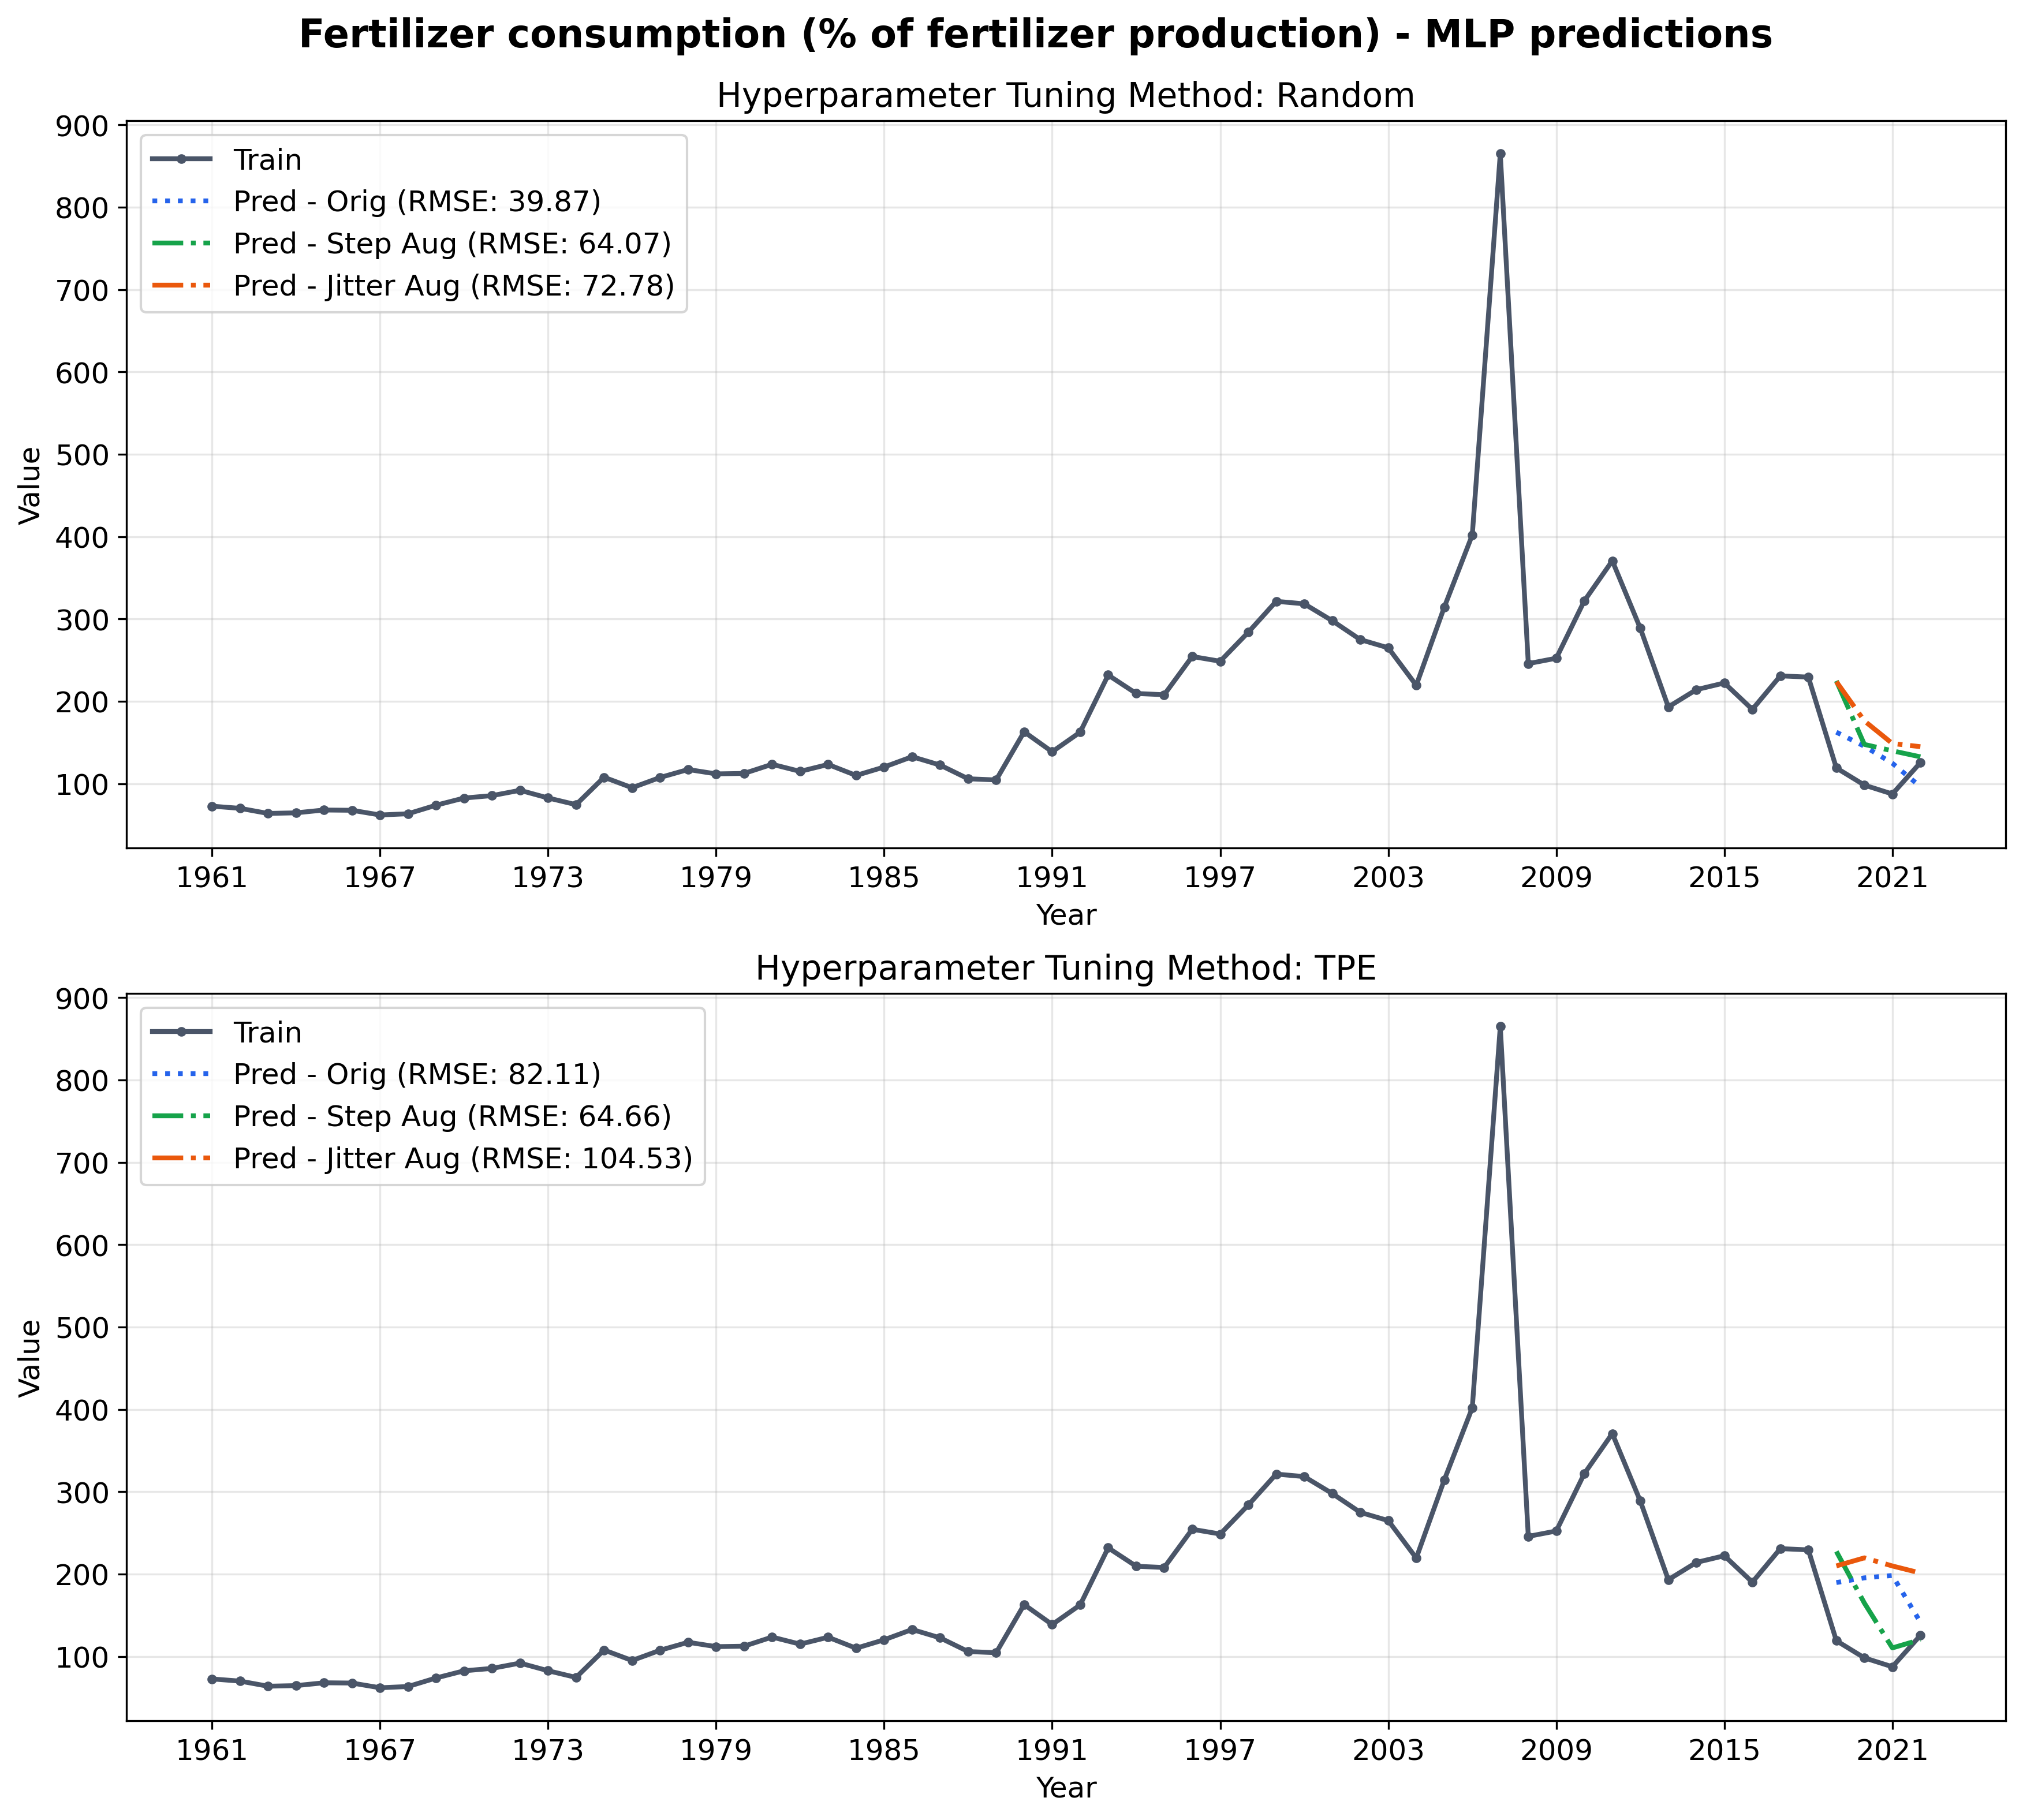

  Random | orig -> years: [2019, 2020, 2021, 2022] preds: [162.548095703125, 145.47470092773438, 124.78160095214844, 96.3998031616211]
  Random | step_aug -> years: [2019, 2020, 2021, 2022] preds: [224.82620239257812, 147.68789672851562, 139.90890502929688, 132.60679626464844]
  Random | jitter_aug -> years: [2019, 2020, 2021, 2022] preds: [223.85279846191406, 176.27940368652344, 148.7471923828125, 144.96080017089844]
  TPE | orig -> years: [2019, 2020, 2021, 2022] preds: [189.73159790039062, 195.43800354003906, 198.2996063232422, 141.7191925048828]
  TPE | step_aug -> years: [2019, 2020, 2021, 2022] preds: [227.47720336914062, 164.8291015625, 110.36620330810547, 120.36360168457031]
  TPE | jitter_aug -> years: [2019, 2020, 2021, 2022] preds: [209.91819763183594, 219.71820068359375, 209.86900329589844, 201.3155975341797]

Plotting predictions for: Agriculture, forestry, and fishing, value added (% of GDP)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\re

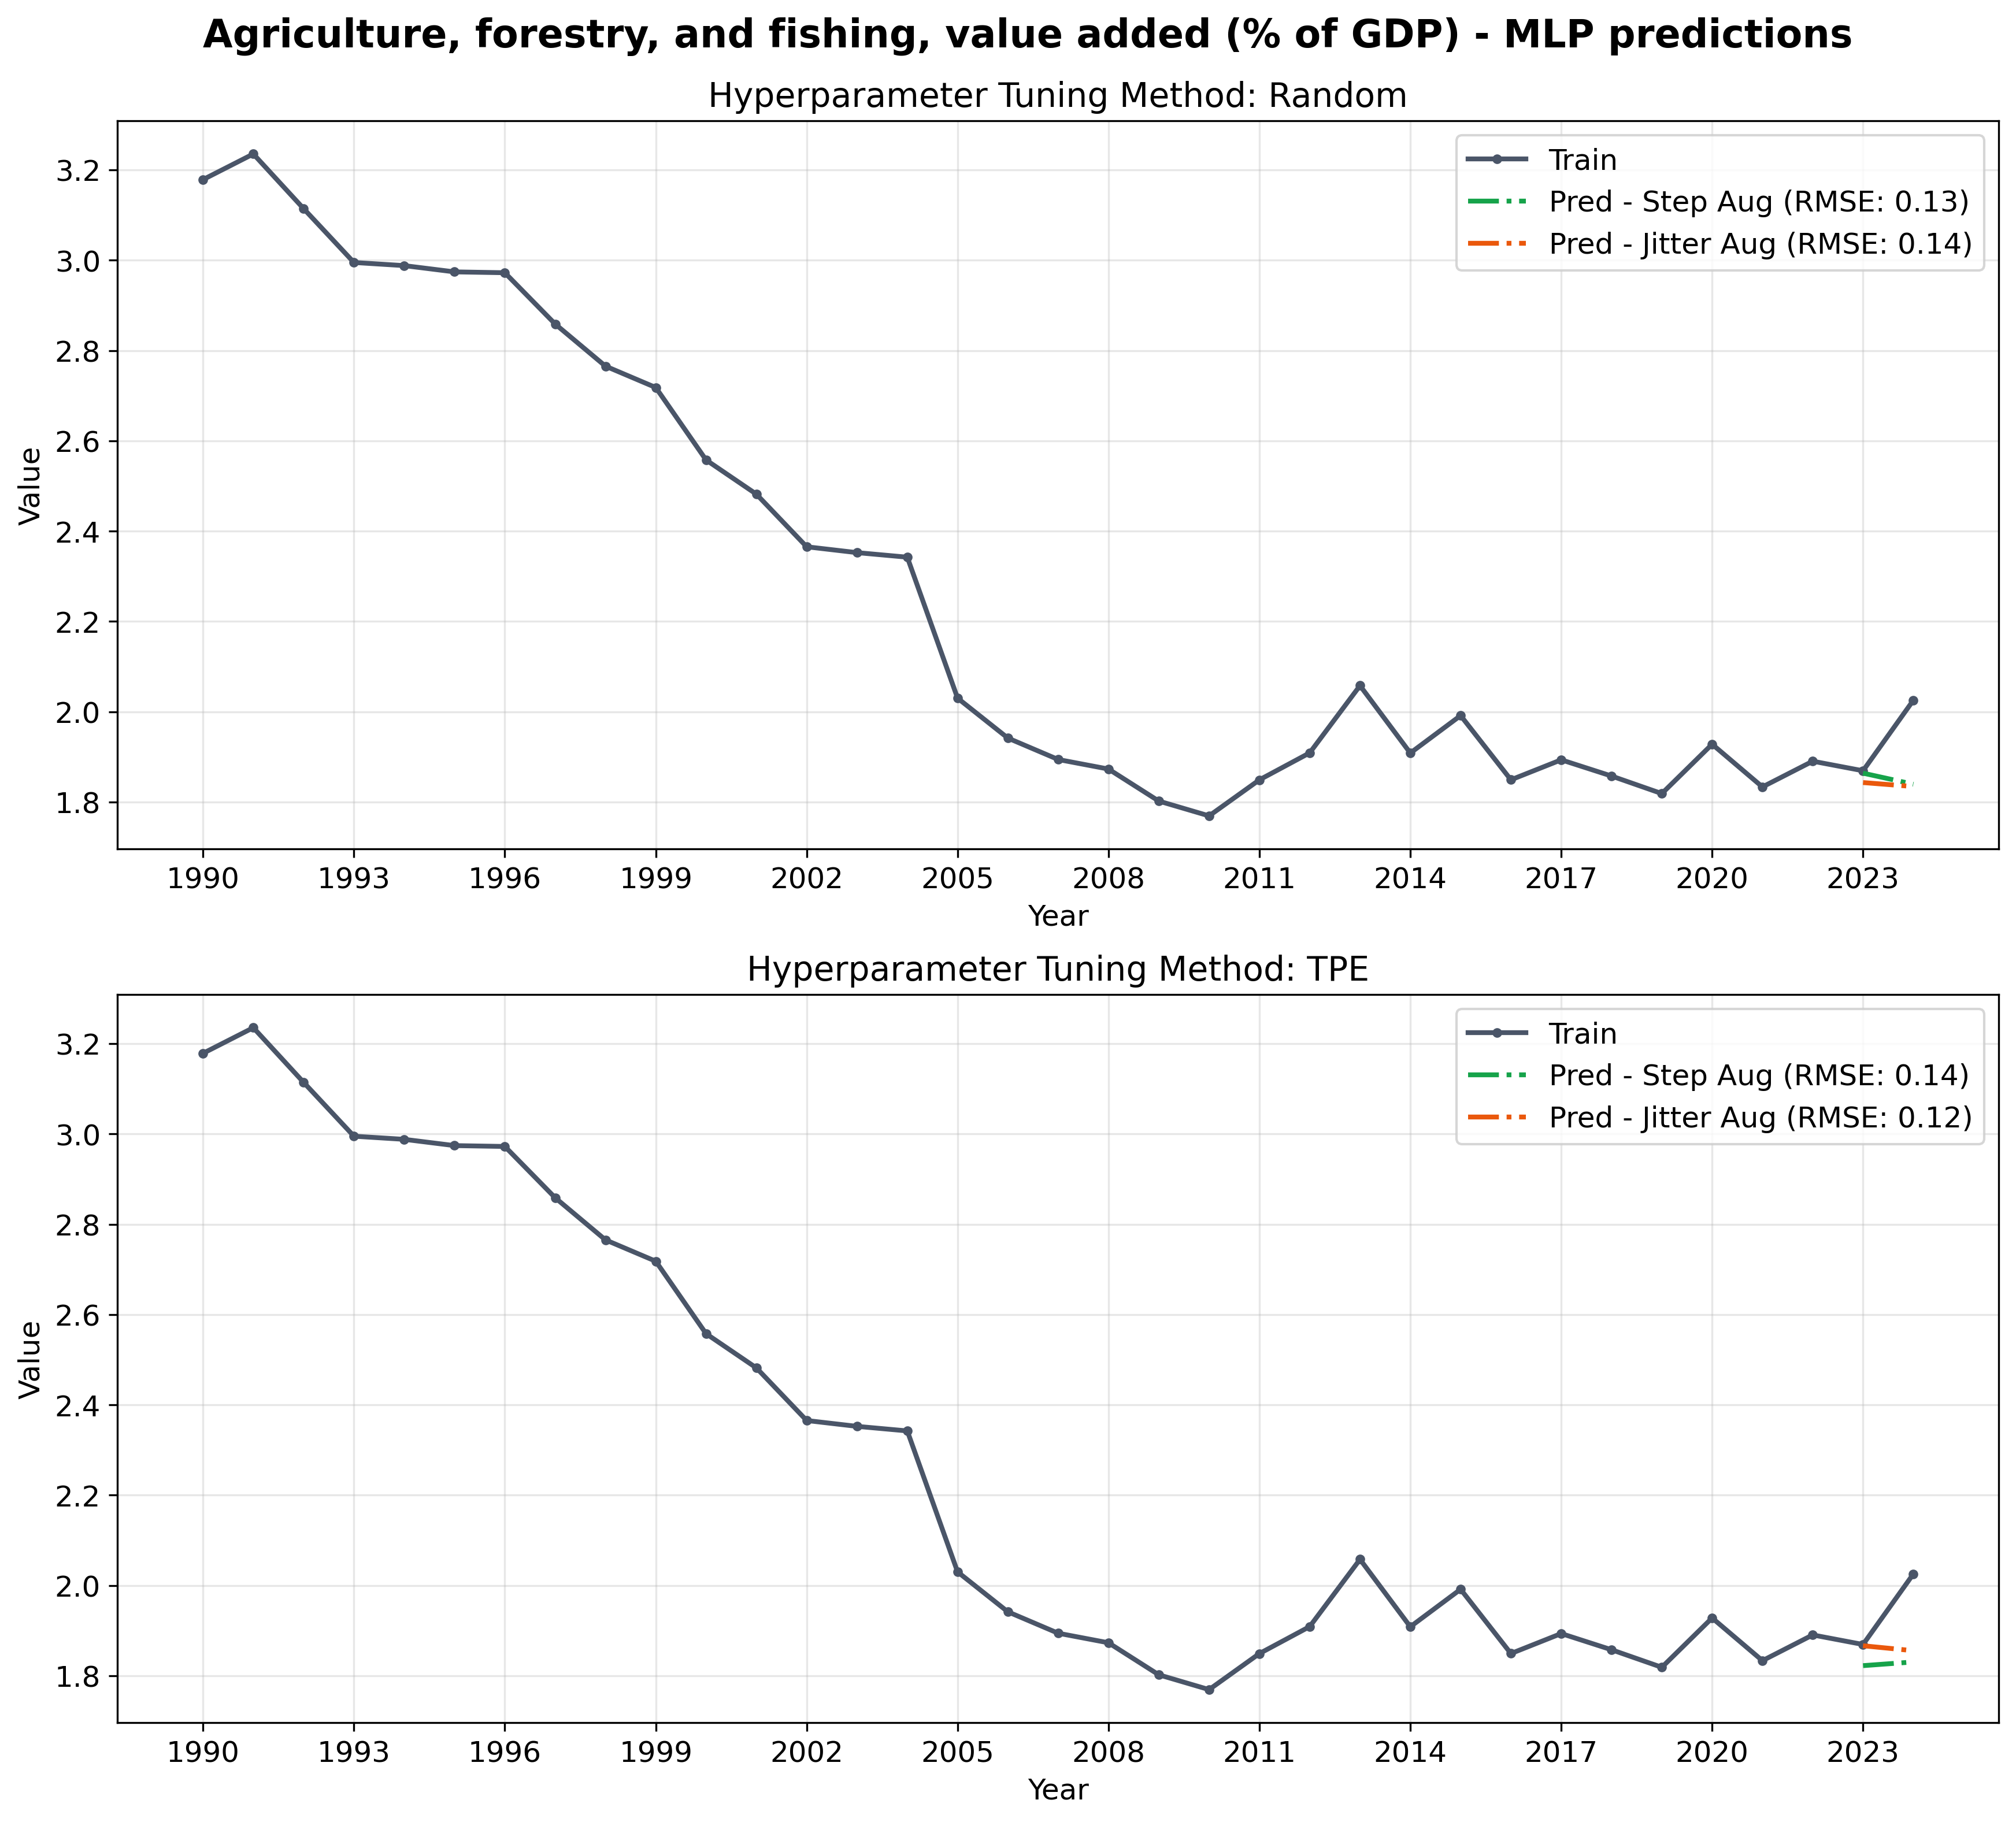

  Random | step_aug -> years: [2023, 2024] preds: [1.8638999462127686, 1.839400053024292]
  Random | jitter_aug -> years: [2023, 2024] preds: [1.8430999517440796, 1.8343000411987305]
  TPE | step_aug -> years: [2023, 2024] preds: [1.8223999738693237, 1.8305000066757202]
  TPE | jitter_aug -> years: [2023, 2024] preds: [1.8664000034332275, 1.8554999828338623]


In [82]:
for indicator in INDICATORS:
    if indicator not in orig_aug_subsets:
        print(f"Skipping {indicator}: missing orig_aug_subsets")
        continue

    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Skipping {indicator}: missing one of orig_train/orig_val/orig_test")
        continue

    if indicator not in predictions_dict:
        print(f"Skipping {indicator}: no predictions available")
        continue

    print(f"\nPlotting predictions for: {indicator}")
    visual.plot_nn_predictions(
        indicator,
        predictions_dict,
        train_orig,
        val_orig,
        test_orig,
        model_name="MLP"
    )

    # optional: print a brief summary of stored predictions per sampler/dataset
    for sampler, cats in predictions_dict[indicator].items():
        for cat, res in cats.items():
            yrs = res.get("years")
            vals = res.get("y_pred")
            if yrs is None or vals is None:
                print(f"  {sampler} | {cat}: missing years or preds")
            else:
                print(f"  {sampler} | {cat} -> years: {yrs.tolist()} preds: {np.round(vals,4).tolist()}")

for ogni_indicatore in 28_indicatori:
    # 1. Ottimizza iperparametri specifici per questa serie
    best_params = hyperparameter_tuning(indicatore_data)
    
    # 2. Training del modello con parametri ottimizzati
    model = train_MLP(data, best_params)
    
    # 3. Calcola metriche
    metrics = calculate_all_metrics(test, predictions)
    
    # 4. Salva metriche con iperparametri
    append_metrics_to_excel(indicatore, 'MLP', metrics)


In [ ]:
future_predictions_dict = {}

for indicator in INDICATORS:
    LAST_DATA_YEAR = int(orig_aug_subsets[indicator]['full_orig']['Year'].iloc[-1])
    TARGET_YEAR = 2030
    # Start prediction horizon from the indicator's own last data year (inclusive)
    future_years = np.arange(LAST_DATA_YEAR, TARGET_YEAR + 1)
    STEPS_AHEAD = len(future_years)

    if indicator not in future_predictions_dict:
        future_predictions_dict[indicator] = {}

    print(f"Forecasting for period: {future_years[0]}-{future_years[-1]}")
    for entry in tuning_results:
        # Ensure we only use tuning results that belong to the current indicator
        if entry['indicator'] != indicator:
            continue

        ind = entry['indicator']
        cat = entry['dataset_type']
        params = entry['best_params']
        sampler = entry['sampler']
        
        if sampler not in future_predictions_dict[indicator]:
            future_predictions_dict[indicator][sampler] = {}
        
        print(f"Forecasting {ind} ({sampler}, {cat})")
        train_part = scaled_orig_aug_subsets[ind][f'{cat}_train']
        val_part   = scaled_orig_aug_subsets[ind]['orig_val']
        test_part  = scaled_orig_aug_subsets[ind]['orig_test']
        
        full_values_scaled = np.concatenate([
            train_part['Value'].values,
            val_part['Value'].values,
            test_part['Value'].values
        ])
        
        n_steps = params['n_input_steps']
        X_full, y_full = pipe.create_sequences(full_values_scaled, n_steps)
        
        model = nn.build_mlp_model(params, input_dim=n_steps)
        
        history, model = nn.train_model(
            model, 
            X_train=X_full, 
            y_train=y_full, 
            X_val=X_full,
            y_val=y_full,
            batch_size=params['batch_size'],
            epochs=150,
            patience=20
        )    
        
        last_window_scaled = full_values_scaled[-n_steps:]
        future_preds_scaled = nn.recursive_forecast(model, last_window_scaled, STEPS_AHEAD)
        
        scaler_y = scalers_subsets[ind]['scaler_y']
        future_preds_real = scaler_y.inverse_transform(future_preds_scaled.reshape(-1, 1)).flatten()
        
        future_predictions_dict[indicator][sampler][cat] = {
            "years": future_years,
            "y_pred": future_preds_real
        }
        
        # # # 7. SALVATAGGIO
        # # # Salviamo nel file CSV dedicato alle predizioni future
        # # rep.save_future_forecasts(
        # #     indicator=ind,
        # #     model_type="MLP",
        # #     config_name=f"{sampler}_{cat}",
        # #     first_future_year=future_years[0],
        # #     y_pred=future_preds_real
        # # )

Forecasting for period: 2022-2030
Forecasting Fertilizer consumption (% of fertilizer production) (Random, orig)
Forecasting Fertilizer consumption (% of fertilizer production) (Random, step_aug)
Forecasting Fertilizer consumption (% of fertilizer production) (Random, jitter_aug)
Forecasting Fertilizer consumption (% of fertilizer production) (TPE, orig)
Forecasting Fertilizer consumption (% of fertilizer production) (TPE, step_aug)
Forecasting Fertilizer consumption (% of fertilizer production) (TPE, jitter_aug)
Forecasting for period: 2024-2030
Forecasting Agriculture, forestry, and fishing, value added (% of GDP) (Random, orig)
Forecasting Agriculture, forestry, and fishing, value added (% of GDP) (Random, step_aug)
Forecasting Agriculture, forestry, and fishing, value added (% of GDP) (Random, jitter_aug)
Forecasting Agriculture, forestry, and fishing, value added (% of GDP) (TPE, orig)
Forecasting Agriculture, forestry, and fishing, value added (% of GDP) (TPE, step_aug)
Forecasti


Plotting future forecast for: Fertilizer consumption (% of fertilizer production)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\MLP_future\MLP_future_fertilizer_percent.png


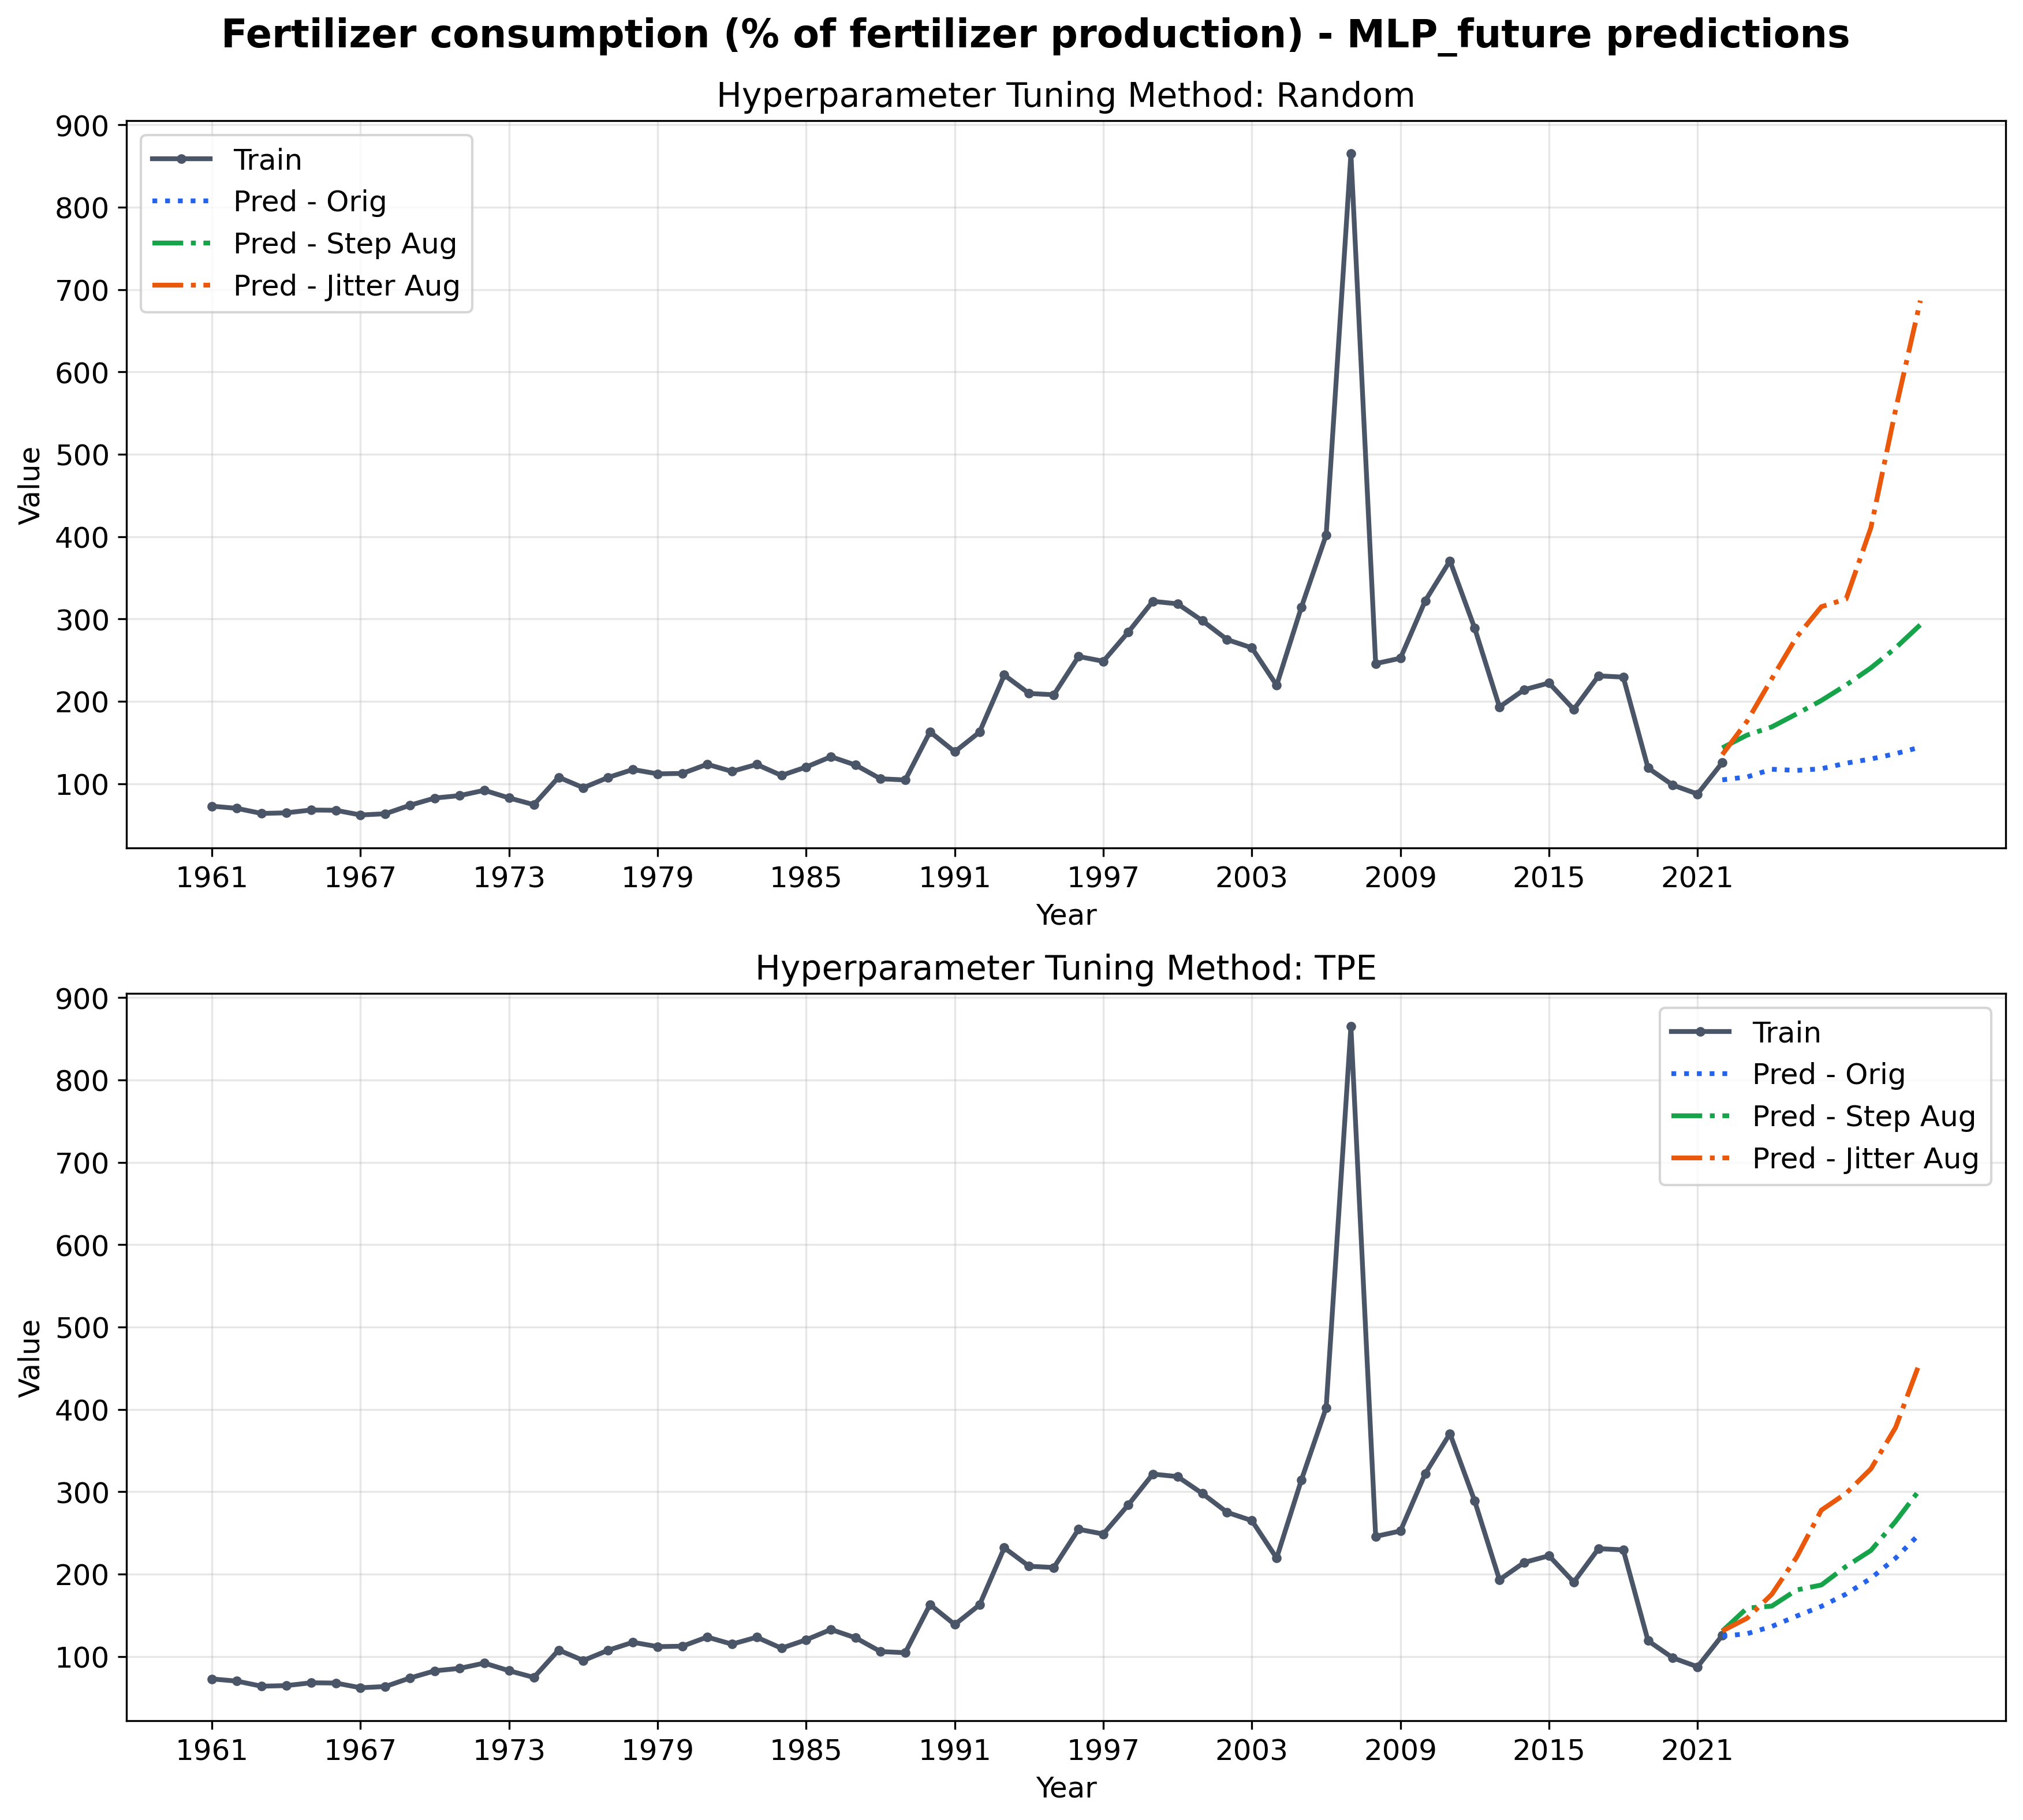

Fertilizer consumption (% of fertilizer production) | Random | orig -> years: [2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [104.6676025390625, 108.11900329589844, 117.55989837646484, 116.08399963378906, 118.14759826660156, 124.89289855957031, 129.9644012451172, 136.41940307617188, 144.39349365234375]
Fertilizer consumption (% of fertilizer production) | Random | step_aug -> years: [2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [143.53419494628906, 158.99490356445312, 168.95860290527344, 184.68319702148438, 200.98809814453125, 219.8000030517578, 240.57640075683594, 264.8684997558594, 293.02520751953125]
Fertilizer consumption (% of fertilizer production) | Random | jitter_aug -> years: [2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [135.3406982421875, 175.82899475097656, 227.4971923828125, 277.98309326171875, 314.87689208984375, 324.27178955078125, 410.6473083496094, 554.2534790039062, 686.52197265625]
Fertilizer consumption (% of fertilize

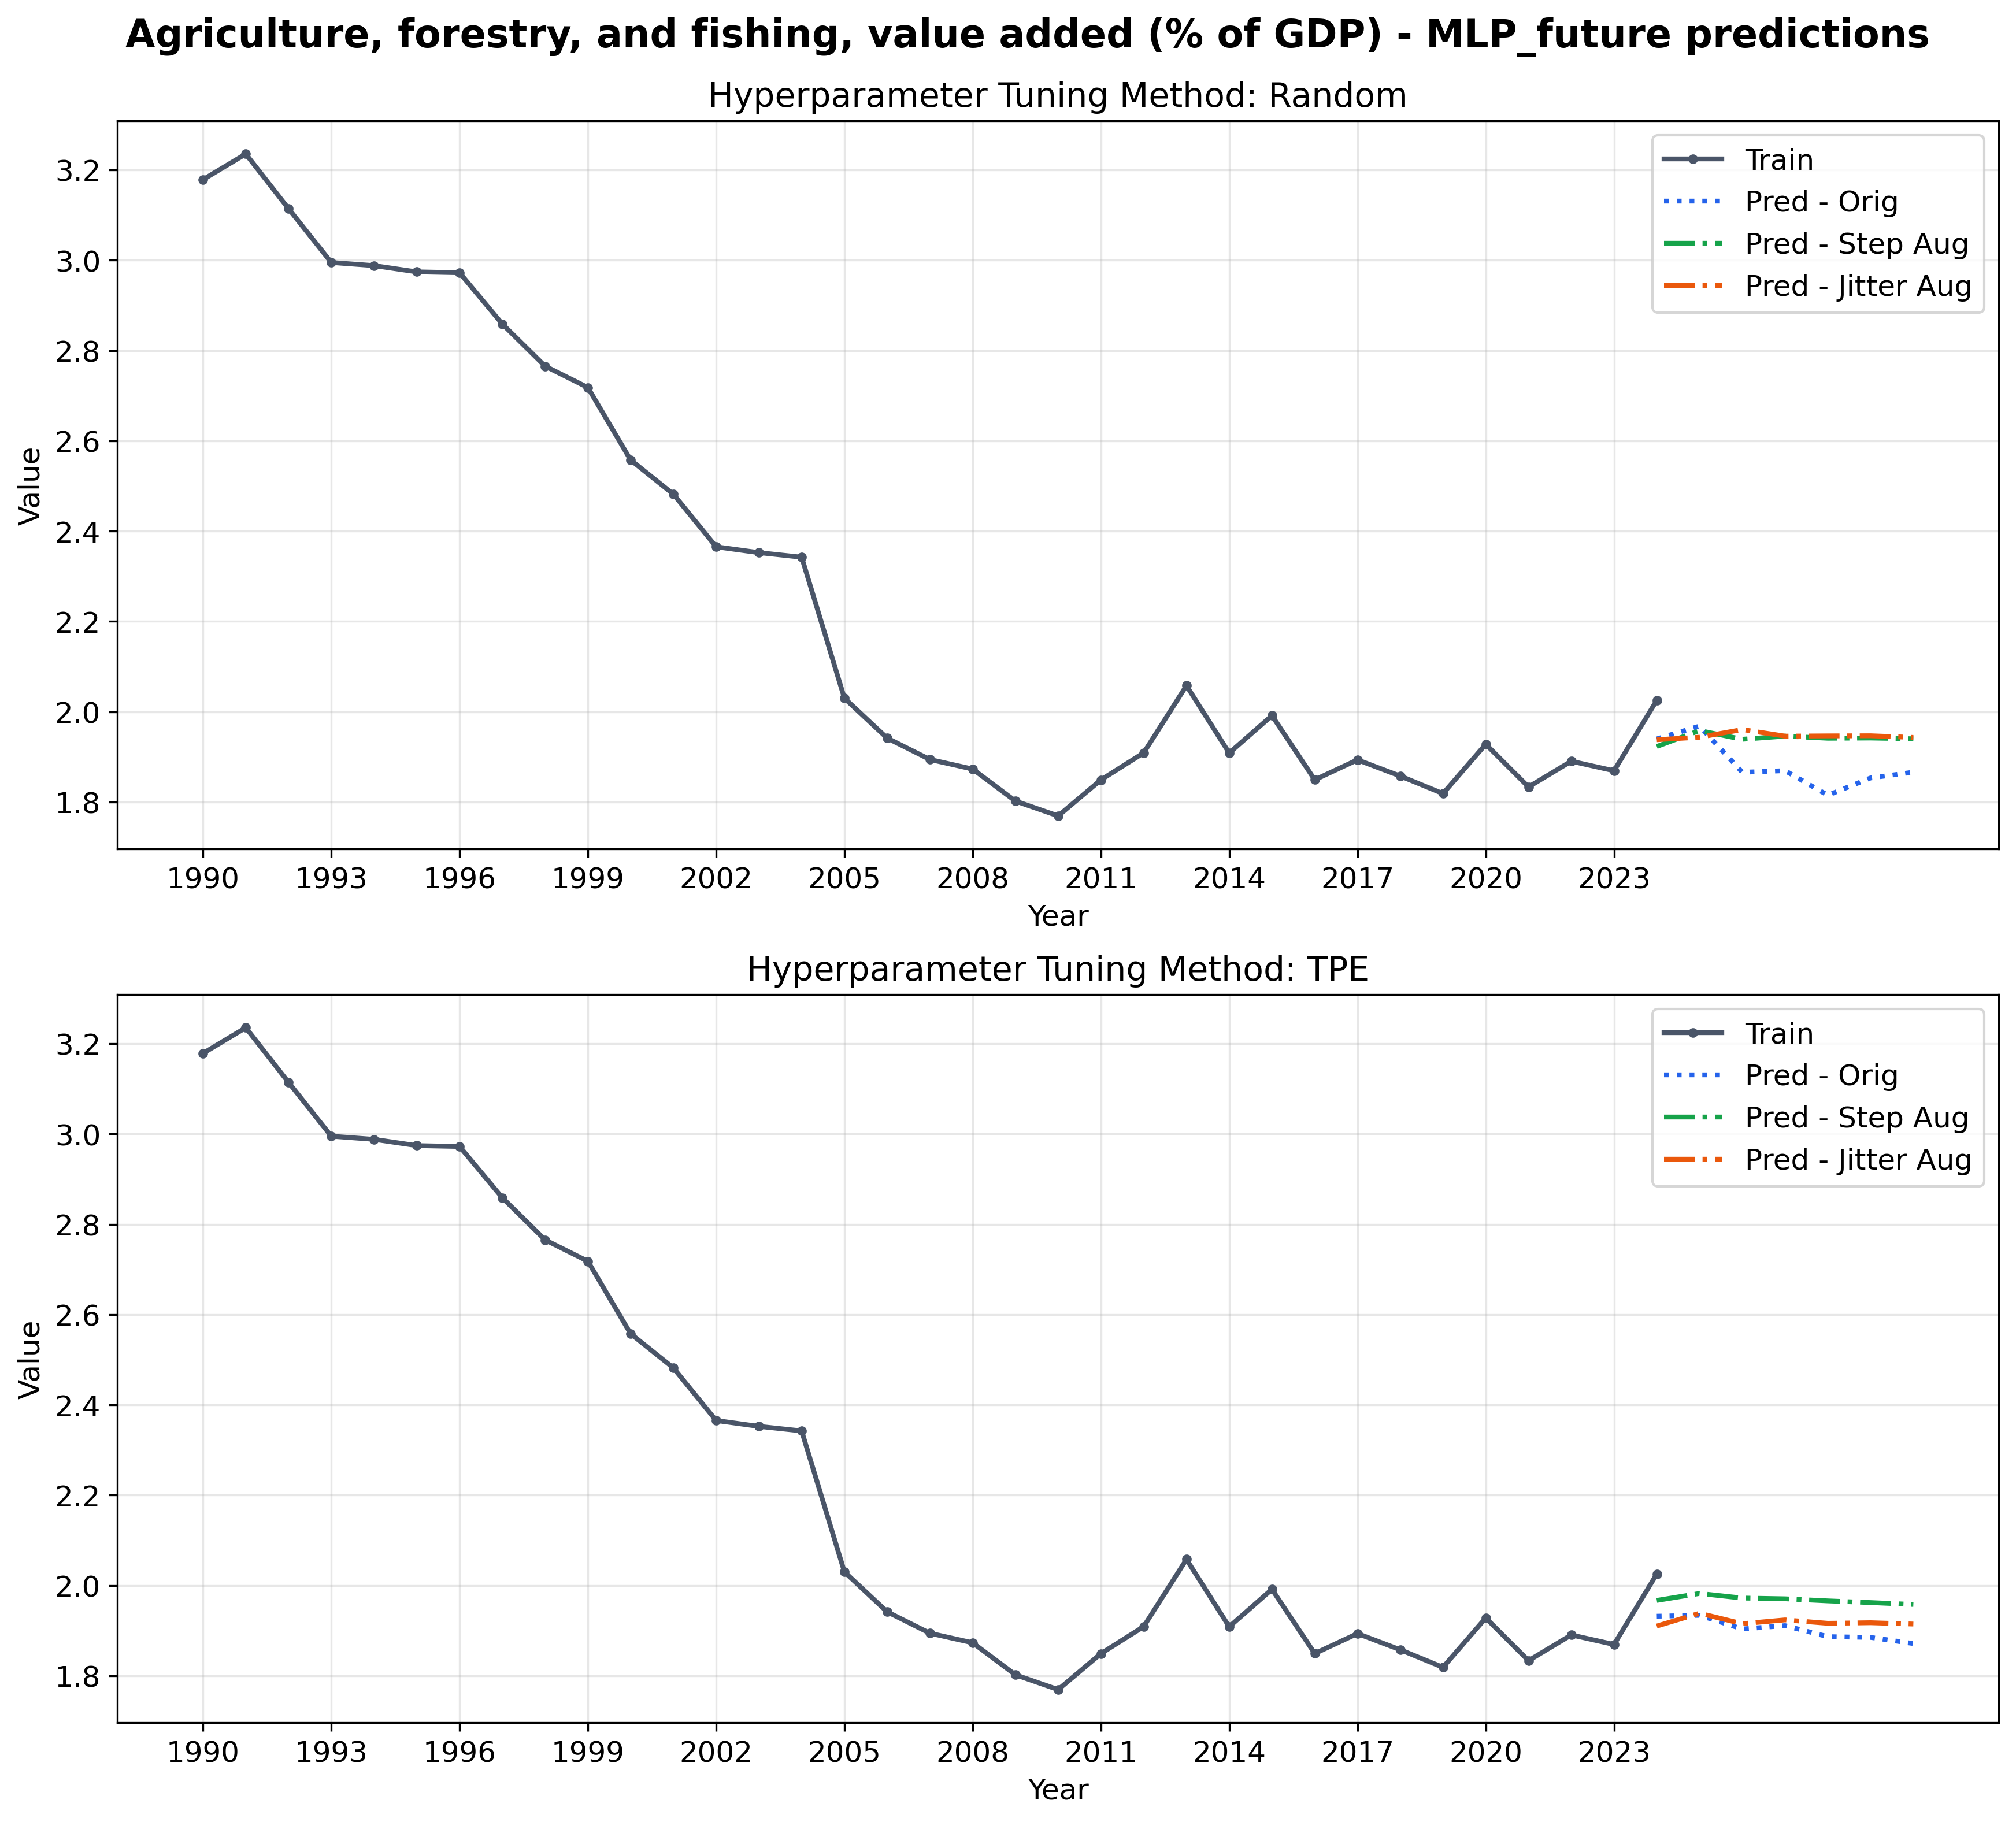

Agriculture, forestry, and fishing, value added (% of GDP) | Random | orig -> years: [2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [1.9397000074386597, 1.9680999517440796, 1.8658000230789185, 1.8695000410079956, 1.815000057220459, 1.8532999753952026, 1.8660000562667847]
Agriculture, forestry, and fishing, value added (% of GDP) | Random | step_aug -> years: [2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [1.9229999780654907, 1.9581999778747559, 1.9390000104904175, 1.9458999633789062, 1.9413000345230103, 1.9416999816894531, 1.9400999546051025]
Agriculture, forestry, and fishing, value added (% of GDP) | Random | jitter_aug -> years: [2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [1.937999963760376, 1.94350004196167, 1.9605000019073486, 1.9458999633789062, 1.9464000463485718, 1.9466999769210815, 1.9430999755859375]
Agriculture, forestry, and fishing, value added (% of GDP) | TPE | orig -> years: [2024, 2025, 2026, 2027, 2028, 2029, 2030] preds: [1.9318000078201294, 1.93379998207

In [84]:
for indicator in future_predictions_dict:
    try:
        train_orig = orig_aug_subsets[indicator]['orig_train']
        val_orig = orig_aug_subsets[indicator]['orig_val']
        test_orig = orig_aug_subsets[indicator]['orig_test']
    except KeyError:
        print(f"Skipping {indicator}: missing original subsets")
        continue

    print(f"\nPlotting future forecast for: {indicator}")
    visual.plot_nn_predictions(
        indicator,
        future_predictions_dict,
        train_orig,
        val_orig,
        test_orig,
        model_name="MLP_future"
    )

    # print corresponding future years and predictions for clarity
    for sampler, cats in future_predictions_dict[indicator].items():
        for cat, pred in cats.items():
            yrs = pred["years"]
            vals = pred["y_pred"]
            print(f"{indicator} | {sampler} | {cat} -> years: {yrs.tolist()} preds: {np.round(vals, 4).tolist()}")